In [1]:
# TTC Subway Delays — Exploratory Data Analysis
#
# Built on the merged dataset from 01_data_preparation.ipynb.
# 97K+ subway delay incidents from 2022-2026, joined with hourly Toronto weather.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Load the prepared dataset
df = pd.read_parquet("../data/processed/ttc_delays_with_weather.parquet")

# Also load the code descriptions for decoding delay codes
codes_df = pd.read_csv("../data/raw/Code_Descriptions.csv")

print(f"Delays: {df.shape}")
print(f"Codes reference: {codes_df.shape}")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")

Delays: (97502, 23)
Codes reference: (140, 3)
Date range: 2022-01-01 01:02:00 → 2026-01-31 23:49:00


In [2]:
# Step 25a: Understand the Min Delay distribution, especially zero-delay incidents.

# 1. How many rows have zero delay?
zero_count = (df['Min Delay'] == 0).sum()
print(f"Rows with Min Delay = 0: {zero_count:,} ({zero_count/len(df)*100:.1f}%)")


# 2. How many rows have a positive delay?
positive_count = (df['Min Delay'] > 0).sum()
print(f"Rows with Min Delay > 0: {positive_count:,} ({positive_count/len(df)*100:.1f}%)")


# 3. Are there any negative delays? (Shouldn't be, but always check.)
negative_count = (df['Min Delay'] < 0).sum()
print(f"Rows with Min Delay < 0: {negative_count:,}")


# 4. Breakdown of delay "buckets" — humans understand bins better than a histogram.
bins = [-1, 0, 2, 5, 10, 20, 60, 1e9]
labels = ['0', '1-2', '3-5', '6-10', '11-20', '21-60', '60+']
buckets = pd.cut(df['Min Delay'], bins=bins, labels=labels)
print("\nDelay buckets:")
print(buckets.value_counts().sort_index())

Rows with Min Delay = 0: 60,809 (62.4%)
Rows with Min Delay > 0: 36,693 (37.6%)
Rows with Min Delay < 0: 0

Delay buckets:
Min Delay
0        60809
1-2         65
3-5      21697
6-10      9092
11-20     3982
21-60     1563
60+        294
Name: count, dtype: int64


In [3]:
# Step 25b: How extreme are the delays on the high end?

# 1. Standard describe() gives us quantiles.
print(df['Min Delay'].describe())


# 2. Extra quantiles for the tail — where does the distribution actually end?
print("\nHigh quantiles:")
for q in [0.90, 0.95, 0.99, 0.999, 1.0]:
    print(f"  {q*100:5.1f}%: {df['Min Delay'].quantile(q):.0f} min")


# 3. What do the longest delays look like? Full incident context.
print("\nTop 10 longest delays:")
df.nlargest(10, 'Min Delay')[
    ['datetime', 'Station', 'Code', 'Min Delay', 'Min Gap', 'weather']
]

count    97502.000000
mean         3.063312
std         11.903961
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max        900.000000
Name: Min Delay, dtype: float64

High quantiles:
   90.0%: 7 min
   95.0%: 12 min
   99.0%: 29 min
   99.9%: 129 min
  100.0%: 900 min

Top 10 longest delays:


,datetime,Station,Code,Min Delay,Min Gap,weather
72626,2025-02-16 11:03:00,SHEPPARD WEST STATION,MUWEA,900,906,"Snow,Blowing Snow"
96941,2026-01-26 05:50:00,WOODBINE STATION,PUTIS,827,0,None
72614,2025-02-16 09:18:00,EGLINTON STATION,MUWEA,807,812,Snow
52669,2024-05-13 07:01:00,BROADVIEW AND ST GEORG,EUCD,716,719,Mostly Cloudy
96943,2026-01-26 05:54:00,ST CLAIR & BLOOR,PUTIS,708,0,None
96866,2026-01-25 15:21:00,VICTORIA PARK STATION,PUTIS,661,665,Heavy Snow
51296,2024-04-25 15:36:00,ISLINGTON TO KIPLING,MUPLB,640,645,None
96873,2026-01-25 16:12:00,GLENCAIRN STATION,PUTIS,622,626,Heavy Snow
96944,2026-01-26 06:00:00,ST CLAIR WEST STATION,PUTIS,505,0,Snow
96884,2026-01-25 17:32:00,EGLINTON AND BLOOR STA,PUTIS,504,508,Heavy Snow


In [4]:
# Step 25c: Which columns have nulls, and do they matter?

# 1. Null count per column, only showing columns that have any nulls.
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(nulls)
print(f"\nRelative to dataset size ({len(df):,} rows):")
print((nulls / len(df) * 100).round(2).astype(str) + '%')

Columns with missing values:
humidex           80107
wind_chill        76256
weather           54428
Bound             33822
wind_dir_10deg     1378
Line                206
dew_point_c          18
temp_c               18
visibility_km        18
wind_speed_kmh       18
humidity_pct         18
pressure_kpa         18
dtype: int64

Relative to dataset size (97,502 rows):
humidex           82.16%
wind_chill        78.21%
weather           55.82%
Bound             34.69%
wind_dir_10deg     1.41%
Line               0.21%
dew_point_c        0.02%
temp_c             0.02%
visibility_km      0.02%
wind_speed_kmh     0.02%
humidity_pct       0.02%
pressure_kpa       0.02%
dtype: object


In [5]:
# Step 25d: What are the most common delay causes?

# 1. Top 15 most frequent codes.
top_codes = df['Code'].value_counts().head(15)
print("Top 15 most frequent delay codes:")
print(top_codes)


# 2. Decode them — join with codes_df to see what they actually mean.
#    codes_df has columns ['_id', 'CODE', 'DESCRIPTION'].
top_codes_decoded = (
    top_codes.reset_index()
    .rename(columns={'Code': 'code', 'count': 'frequency'})
    .merge(codes_df, left_on='code', right_on='CODE', how='left')
    [['code', 'frequency', 'DESCRIPTION']]
)
print("\nDecoded:")
top_codes_decoded

Top 15 most frequent delay codes:
Code
SUDP     12035
MUIS      9899
SUO       7721
MUPAA     6066
PUOPO     4963
MUIRS     4933
MUO       3974
PUMEL     2943
MUIR      2674
SUUT      2576
MUNCA     2565
SUAP      2493
MUSC      2410
TUSC      1640
MUI       1532
Name: count, dtype: int64

Decoded:


,code,frequency,DESCRIPTION
0,SUDP,12035,DISORDERLY PATRON
1,MUIS,9899,INJURED/ILL CUSTOMER IN STATION - TRANSPORTED
2,SUO,7721,SECURITY OTHER
3,MUPAA,6066,PAA â NO TROUBLE FOUND
4,PUOPO,4963,OPTO (COMMUNICATIONS) TRAIN DOOR MONITORING
5,MUIRS,4933,INJURED/ILL CUSTOMER IN STATION â MEDICAL AI...
6,MUO,3974,MISCELLANEOUS OTHER
7,PUMEL,2943,ANY ESCL. OR ELEV. INCIDENT â TRANSPORTED OR...
8,MUIR,2674,INJURED/ILL CUSTOMER ON TRAIN â MEDICAL AID ...
9,SUUT,2576,UNAUTHORIZED AT TRACK LEVEL


In [12]:
# Step 25e: Year-over-year trend in incident count and average delay.

yearly = df.groupby('source_year').agg(
    incidents=('Min Delay', 'size'),
    mean_delay=('Min Delay', 'mean'),
    median_delay=('Min Delay', 'median'),
    total_delay_minutes=('Min Delay', 'sum'),
)
print(yearly.round(2))


# Note: 2025 is partial (up to Jan 31, 2026 in the data), so don't 
# read too much into that year's totals.

             incidents  mean_delay  median_delay  total_delay_minutes
source_year                                                          
2022             19895        3.67           0.0                73106
2023             22949        2.97           0.0                68179
2024             26467        2.81           0.0                74274
2025             28191        2.95           0.0                83120


## Data quality findings

**Target distribution**
- 62.4% of rows have Min Delay = 0 (logged incidents that didn't actually
  hold trains). For regression, I'll filter to Min Delay > 0.
- Distribution is heavily right-skewed: median 0, mean ~3 min, 99th
  percentile ~60 min, max 900 min (15hr Feb 2025 snowstorm shutdown).
- Will cap delays at the 99th percentile for modeling.

**Missingness**
- `humidex` (82%) and `wind_chill` (78%) — only computed in extreme temps;
  will drop these columns entirely.
- `weather` (56%) — NaN indicates unremarkable/clear conditions; will
  fill with "Clear".
- `Bound` (35%) — legitimately missing for non-revenue incidents.
- All other columns < 1.5% missing — negligible.

**Top delay causes (surprising)**
1. Disorderly patron (12K)
2. Ill customer in station (10K)
3. Security-other (8K)
Social/medical issues dominate — not weather or mechanical failures.

**Year-over-year trend**
- Incidents grew 42% from 2022 to 2024 (19,895 → 26,467), 2025 on pace
  for similar growth.
- Mean delay per incident has actually *decreased* slightly (3.67 → 2.81).
- Interpretation: more events being logged, but they aren't worse
  individually.

Working with 36,693 actual delays (Min Delay > 0)


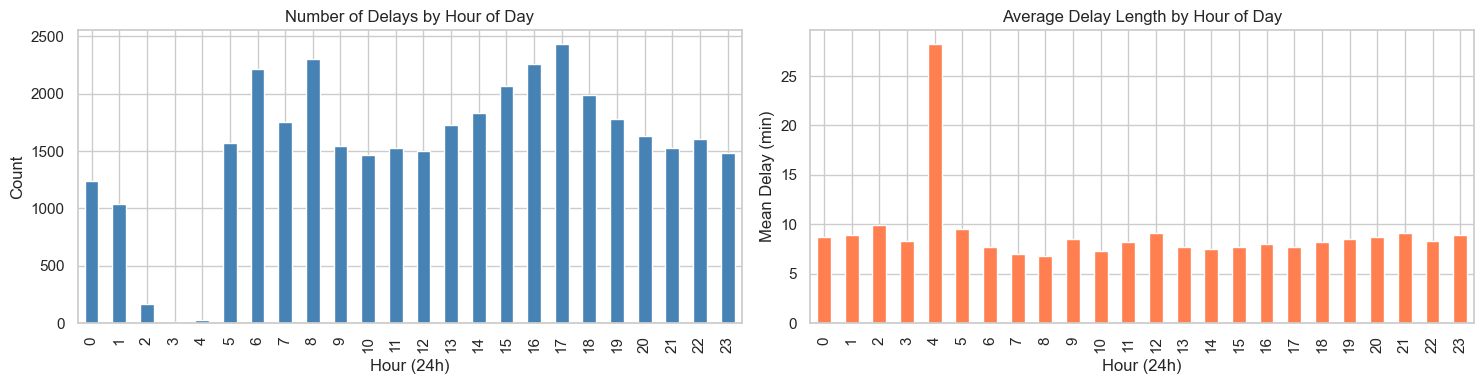

In [8]:
# Step 27a: Delay volume by hour of day and day of week.
# Only considering actual delays (Min Delay > 0), since zeros are noise here.

delays_only = df[df['Min Delay'] > 0].copy()
delays_only['hour'] = delays_only['datetime'].dt.hour
delays_only['day_of_week'] = delays_only['datetime'].dt.dayofweek  # 0=Mon

print(f"Working with {len(delays_only):,} actual delays (Min Delay > 0)")


# 1. Average delay by hour of day
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

delays_only.groupby('hour').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Delays by Hour of Day')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Hour (24h)')

delays_only.groupby('hour')['Min Delay'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Delay Length by Hour of Day')
axes[1].set_ylabel('Mean Delay (min)')
axes[1].set_xlabel('Hour (24h)')

plt.tight_layout()
plt.show()

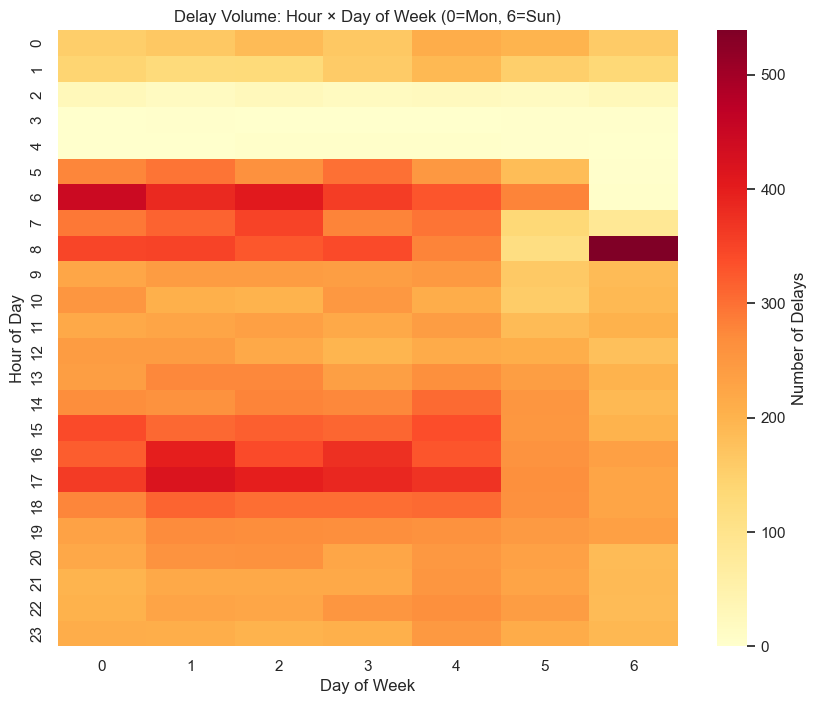

In [9]:
# Step 27b: Heatmap — hour × day of week for delay COUNTS.
# This will show the rush hour spike vividly.

pivot_count = delays_only.pivot_table(
    values='Min Delay', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='size',
    fill_value=0,
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_count, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Number of Delays'})
plt.title('Delay Volume: Hour × Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Hour of Day')
plt.xlabel('Day of Week')
plt.show()

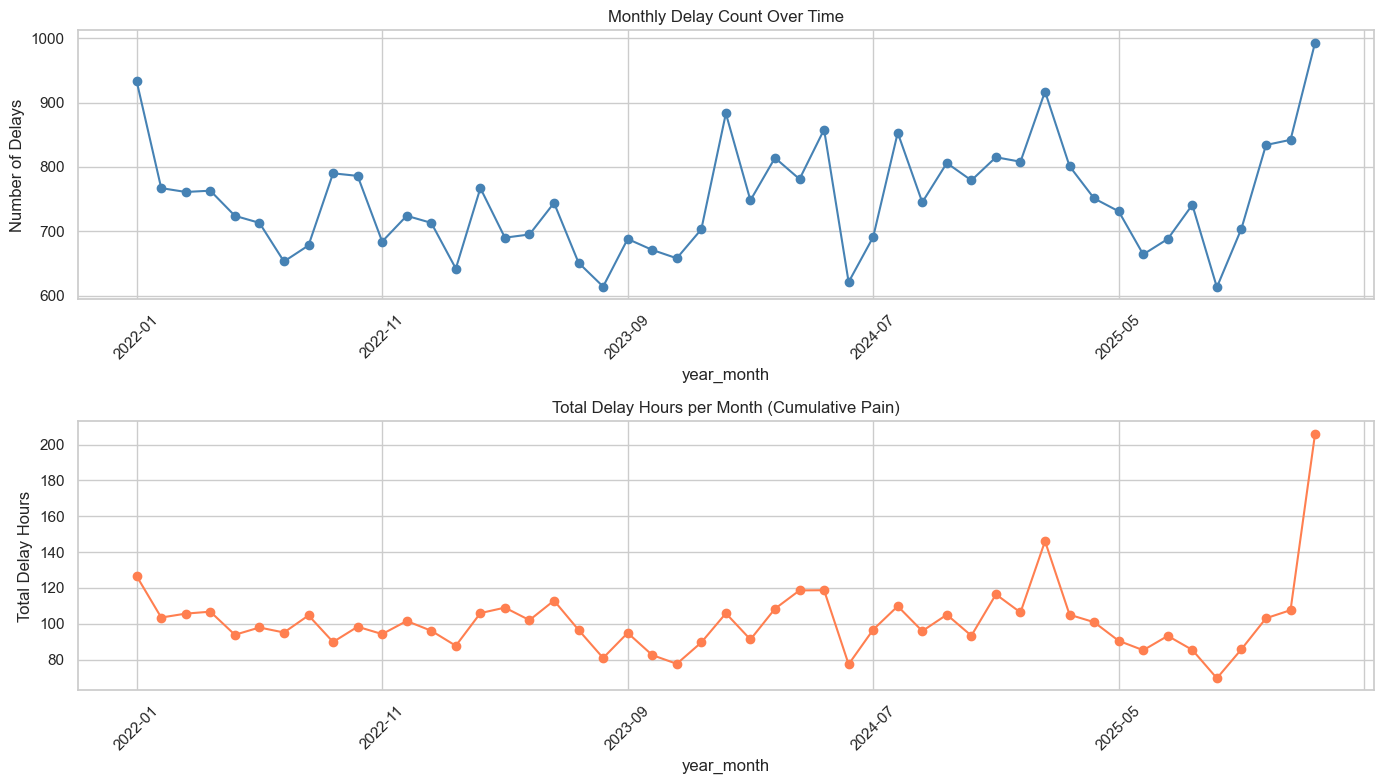

In [10]:
# Step 27c: Monthly trend over time.
# Is there a seasonal pattern? Are things getting worse?

delays_only['year_month'] = delays_only['datetime'].dt.to_period('M').astype(str)
monthly = delays_only.groupby('year_month').agg(
    incident_count=('Min Delay', 'size'),
    avg_delay=('Min Delay', 'mean'),
    total_delay_hours=('Min Delay', lambda x: x.sum() / 60),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

monthly['incident_count'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Monthly Delay Count Over Time')
axes[0].set_ylabel('Number of Delays')
axes[0].tick_params(axis='x', rotation=45)

monthly['total_delay_hours'].plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Total Delay Hours per Month (Cumulative Pain)')
axes[1].set_ylabel('Total Delay Hours')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

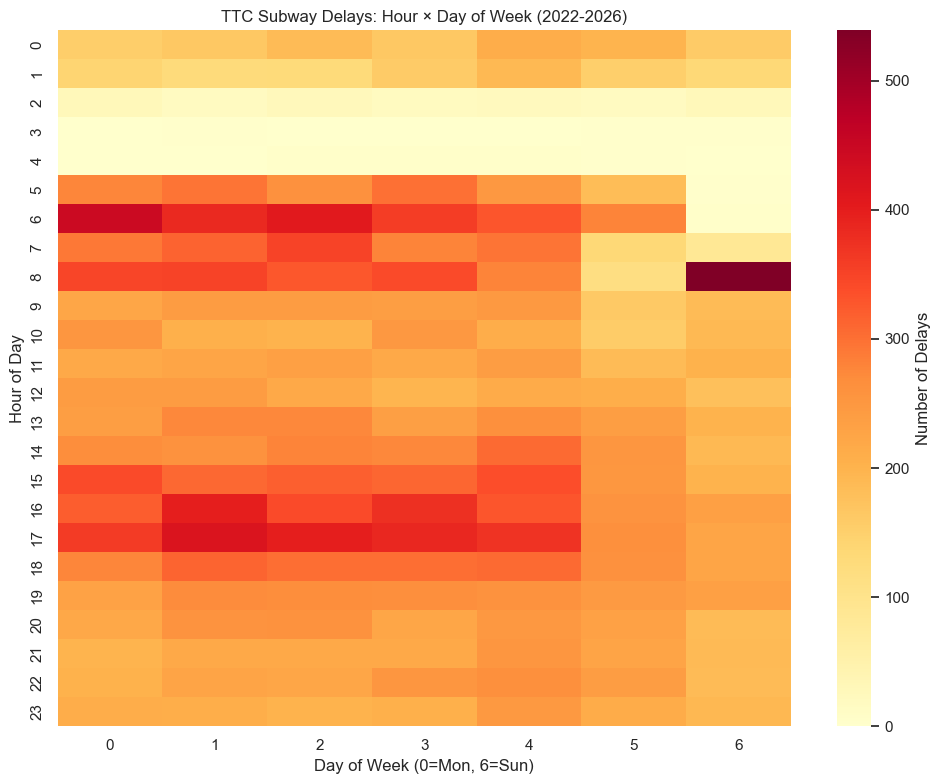

In [11]:
# At the end of the temporal analysis, save the heatmap
fig = plt.figure(figsize=(10, 8))
sns.heatmap(pivot_count, cmap='YlOrRd', cbar_kws={'label': 'Number of Delays'})
plt.title('TTC Subway Delays: Hour × Day of Week (2022-2026)')
plt.ylabel('Hour of Day')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.tight_layout()
plt.savefig('../reports/figures/delays_hour_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()

## Temporal patterns

- **Rush hours dominate delay *frequency***, not *length*. Mean delay length 
  is stable at ~8 min regardless of hour; there are just far more incidents 
  during commute times.
- **Bimodal daily pattern**: morning rush (7-9am) and evening rush (4-7pm) 
  each produce ~2,000+ delays per hour in the data.
- **Weekends are quieter** (roughly 40% fewer delays) except for a curious 
  Sunday 8am spike — worth investigating later.
- **The data shows worsening delays recently**: monthly counts trend upward 
  from ~700/mo in 2023 to ~900+/mo in late 2025.
- **Jan 2026 is a major outlier**: 200+ hours of total delays, dominated by 
  a single multi-day snowstorm event. Worth flagging to the reader.